# Email Spam Classification

**Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

**Loading Dataset**

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/spam.csv', encoding='latin1')

In [ ]:
display(df.head())
display(df.tail())

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN
5571,ham,Rofl. Its true to its name,NaN,NaN,NaN


**Data Cleaning**

In [ ]:
df = df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'])
df.columns = ['label', 'text']

In [ ]:
display(df.head())

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


**Label Encoding**

In [ ]:
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

**Feature Extraction**

In [ ]:
#we convert text into number
tfidf = TfidfVectorizer(stop_words='english', lowercase=True)
X = tfidf.fit_transform(df['text'])
y = df['label']

**Train-Test Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Model Training**

In [ ]:
model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

**Model Evaluation**

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print("--- Model Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

--- Model Performance ---
Accuracy: 96.86%

Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.77      0.87       150

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.93      1115
weighted avg       0.97      0.97      0.97      1115



**Confusion Matrix Visualization**

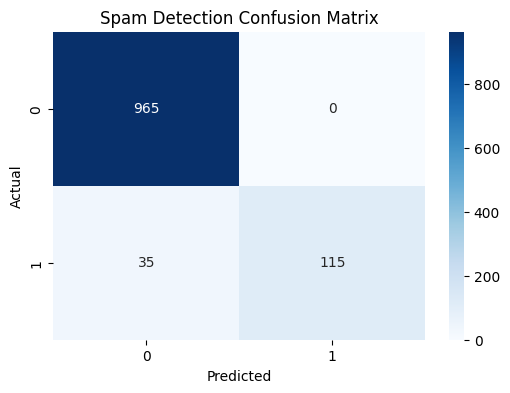

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Spam Detection Confusion Matrix')
plt.show()

**Test with your own email!**

In [ ]:
def predict_email(msg):
    msg_tfidf = tfidf.transform([msg])
    prediction = model.predict(msg_tfidf)
    return "SPAM" if prediction[0] == 1 else "NOT SPAM (HAM)"

print("\nExample Test:")
print(predict_email("You are hire in my company."))


Example Test:
NOT SPAM (HAM)
